# Experiment: 2x2 Evaluation of BERT Artifacts

Objective:
- Compare **base vs fine-tuned** and **review_text_only vs review_text_app_info** (2x2).
- Use prompt variants (`decimal_*`, `words_*`) to measure robustness.
- Diagnose prediction collapse behavior (for example, over-predicting label `5` on decimal prompts).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

ARTIFACT_ROOT = Path("models") / "bert_finetuned_mlm"
VARIANT_ARTIFACT_PATHS = {
    "review_text_only": ARTIFACT_ROOT / "review_text_only" / "artifacts",
    "review_text_app_info": ARTIFACT_ROOT / "review_text_app_info" / "artifacts",
}

VARIANT_ORDER = ["review_text_only", "review_text_app_info"]
STAGE_ORDER = ["base", "finetuned"]

for variant, path in VARIANT_ARTIFACT_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing artifacts for {variant}: {path}")

print("Artifact directories:")
for variant in VARIANT_ORDER:
    print(f"- {variant}: {VARIANT_ARTIFACT_PATHS[variant]}")


Artifact directories:
- review_text_only: models\bert_finetuned_mlm\review_text_only\artifacts
- review_text_app_info: models\bert_finetuned_mlm\review_text_app_info\artifacts


## Load Summary Artifacts

Load run configs and `prompt_comparison_summary.csv`, then reshape metrics into a long format with explicit `stage` (`base` or `finetuned`).


In [2]:
def load_variant_bundle(variant: str, artifacts_root: Path) -> dict:
    summary_path = artifacts_root / "prompt_comparison_summary.csv"
    config_path = artifacts_root / "run_config.json"

    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary file: {summary_path}")
    if not config_path.exists():
        raise FileNotFoundError(f"Missing run config: {config_path}")

    summary_df = pd.read_csv(summary_path)
    summary_df["variant"] = variant

    with config_path.open("r", encoding="utf-8") as f:
        run_config = json.load(f)

    return {
        "variant": variant,
        "summary_wide": summary_df,
        "run_config": run_config,
        "artifacts_root": artifacts_root,
    }


def wide_to_stage_long(summary_wide: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in summary_wide.iterrows():
        for stage in STAGE_ORDER:
            rows.append({
                "variant": row["variant"],
                "prompt_id": row["prompt_id"],
                "prompt": row["prompt"],
                "label_col": row["label_col"],
                "prompt_family": str(row["prompt_id"]).split("_")[0],
                "stage": stage,
                "loss": row[f"{stage}_loss"],
                "accuracy": row[f"{stage}_accuracy"],
                "macro_f1": row[f"{stage}_macro_f1"],
                "mean_true_prob": row[f"{stage}_mean_true_prob"],
            })

    return pd.DataFrame(rows)


bundles = {
    variant: load_variant_bundle(variant, path)
    for variant, path in VARIANT_ARTIFACT_PATHS.items()
}

summary_wide_all = pd.concat(
    [bundles[v]["summary_wide"] for v in VARIANT_ORDER],
    ignore_index=True,
)
summary_long_all = wide_to_stage_long(summary_wide_all)

config_rows = []
for variant in VARIANT_ORDER:
    cfg = bundles[variant]["run_config"]
    config_rows.append({
        "variant": variant,
        "text_col": cfg.get("text_col"),
        "max_length": cfg.get("max_length"),
        "batch_size": cfg.get("batch_size"),
        "epochs": cfg.get("epochs"),
        "learning_rate": cfg.get("learning_rate"),
        "weight_decay": cfg.get("weight_decay"),
        "prompt_ids": ", ".join(cfg.get("prompt_ids", [])),
    })

config_df = pd.DataFrame(config_rows)
display(config_df)

display(summary_wide_all.sort_values(["label_col", "prompt_id", "variant"]).reset_index(drop=True))


,variant,text_col,max_length,batch_size,epochs,learning_rate,weight_decay,prompt_ids
0,review_text_only,review_text_cleaned,320,16,3,0.00005,0.01,"decimal_0, decimal_1, words_0, words_1, words_2"
1,review_text_app_info,review_info_text_cleaned,384,16,3,0.00005,0.01,"decimal_0, decimal_1, words_0, words_1, words_2"


,prompt_id,prompt,label_col,text_variant,label_words,loaded_from_checkpoint,base_loss,base_accuracy,base_macro_f1,base_mean_true_prob,finetuned_loss,finetuned_accuracy,finetuned_macro_f1,finetuned_mean_true_prob,delta_accuracy,delta_macro_f1,delta_mean_true_prob,variant
0,decimal_0,On a scale from 0.0 to 1.0 this review is 0.[M...,label_funny_minmax,review_text_app_info,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",True,2.487301,0.029167,0.007697,0.113580,1.286203,0.606250,0.160892,0.516263,0.577083,0.153195,0.402683,review_text_app_info
1,decimal_0,On a scale from 0.0 to 1.0 this review is 0.[M...,label_funny_minmax,review_text_only,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",True,2.917141,0.022917,0.005355,0.079459,1.379127,0.566667,0.154686,0.489766,0.543750,0.149332,0.410308,review_text_only
2,decimal_1,On a scale from 0 to 1 this review is 0.[MASK]...,label_funny_minmax,review_text_app_info,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",True,3.976582,0.022917,0.005959,0.044290,1.373142,0.595833,0.171044,0.520562,0.572917,0.165085,0.476272,review_text_app_info
3,decimal_1,On a scale from 0 to 1 this review is 0.[MASK]...,label_funny_minmax,review_text_only,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",True,4.381795,0.022917,0.005950,0.040479,1.437238,0.566667,0.157527,0.478107,0.543750,0.151577,0.437628,review_text_only
4,words_0,"Overall, the humor is [MASK].",label_votes_funny_categorical,review_text_app_info,"serious, witty, amusing, hilarious, hysterical",True,7.128922,0.103000,0.080288,0.163000,1.057895,0.567000,0.286778,0.496686,0.464000,0.206489,0.333686,review_text_app_info
5,words_0,"Overall, the humor is [MASK].",label_votes_funny_categorical,review_text_only,"serious, witty, amusing, hilarious, hysterical",True,7.941842,0.069000,0.043560,0.094949,1.232020,0.520000,0.271549,0.465079,0.451000,0.227989,0.370130,review_text_only
6,words_1,Overall the humor of this review is [MASK].,label_votes_funny_categorical,review_text_app_info,"serious, witty, amusing, hilarious, hysterical",True,7.138186,0.098000,0.039636,0.151298,1.079273,0.568000,0.285077,0.496230,0.470000,0.245441,0.344932,review_text_app_info
7,words_1,Overall the humor of this review is [MASK].,label_votes_funny_categorical,review_text_only,"serious, witty, amusing, hilarious, hysterical",True,7.419559,0.069000,0.041195,0.107345,1.185594,0.520000,0.247378,0.465673,0.451000,0.206182,0.358328,review_text_only
8,words_2,The humor in this review is [MASK].,label_votes_funny_categorical,review_text_app_info,"serious, witty, amusing, hilarious, hysterical",True,6.841266,0.085000,0.051298,0.142786,1.040566,0.563000,0.270739,0.493715,0.478000,0.219441,0.350930,review_text_app_info
9,words_2,The humor in this review is [MASK].,label_votes_funny_categorical,review_text_only,"serious, witty, amusing, hilarious, hysterical",True,7.098552,0.038000,0.038923,0.095450,1.224193,0.541000,0.272802,0.473576,0.503000,0.233879,0.378126,review_text_only


## 2x2 Core Comparison

Rows = text variant, columns = model stage (`base`, `finetuned`).


In [3]:
two_by_two = (
    summary_long_all
    .groupby(["variant", "stage"], as_index=False)[["accuracy", "macro_f1", "mean_true_prob", "loss"]]
    .mean()
)

two_by_two["variant"] = pd.Categorical(two_by_two["variant"], categories=VARIANT_ORDER, ordered=True)
two_by_two["stage"] = pd.Categorical(two_by_two["stage"], categories=STAGE_ORDER, ordered=True)
two_by_two = two_by_two.sort_values(["variant", "stage"]).reset_index(drop=True)

print("2x2 mean metrics across prompts:")
display(two_by_two.round(4))

for metric in ["accuracy", "macro_f1", "mean_true_prob", "loss"]:
    pivot = two_by_two.pivot(index="variant", columns="stage", values=metric)
    display(pivot.round(4))


2x2 mean metrics across prompts:


,variant,stage,accuracy,macro_f1,mean_true_prob,loss
0,review_text_only,base,0.0444,0.0270,0.0835,5.9518
1,review_text_only,finetuned,0.5429,0.2208,0.4744,1.2916
2,review_text_app_info,base,0.0676,0.0370,0.1230,5.5145
3,review_text_app_info,finetuned,0.5800,0.2349,0.5047,1.1674


stage,base,finetuned
variant,,
review_text_only,0.0444,0.5429
review_text_app_info,0.0676,0.5800


stage,base,finetuned
variant,,
review_text_only,0.027,0.2208
review_text_app_info,0.037,0.2349


stage,base,finetuned
variant,,
review_text_only,0.0835,0.4744
review_text_app_info,0.1230,0.5047


stage,base,finetuned
variant,,
review_text_only,5.9518,1.2916
review_text_app_info,5.5145,1.1674


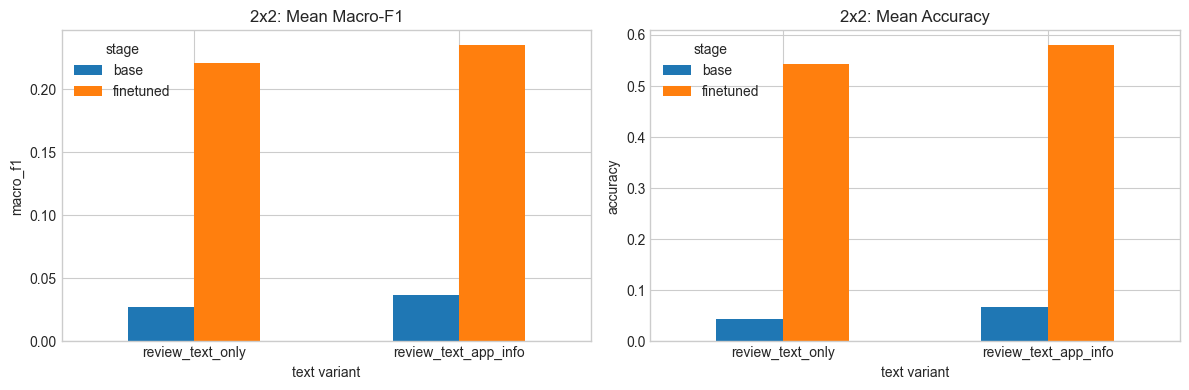

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], "macro_f1", "2x2: Mean Macro-F1"),
    (axes[1], "accuracy", "2x2: Mean Accuracy"),
]:
    pivot = two_by_two.pivot(index="variant", columns="stage", values=metric).loc[VARIANT_ORDER, STAGE_ORDER]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("text variant")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()


## 2x2 Deltas and Cross-Variant Gains

- `delta_*` = fine-tuned minus base inside each text variant.
- `app_info_minus_text_only` compares text variants at the same stage.


In [5]:
delta_by_prompt = summary_wide_all[[
    "variant", "prompt_id", "label_col", "delta_accuracy", "delta_macro_f1", "delta_mean_true_prob"
]].copy()

print("Fine-tuning lift by prompt:")
display(delta_by_prompt.sort_values(["label_col", "delta_macro_f1"], ascending=[True, False]).round(4))

cross_variant = summary_wide_all.pivot_table(
    index=["prompt_id", "label_col"],
    columns="variant",
    values=["base_accuracy", "finetuned_accuracy", "base_macro_f1", "finetuned_macro_f1", "delta_accuracy", "delta_macro_f1"],
    aggfunc="first",
)

cross_variant.columns = [f"{metric}__{variant}" for metric, variant in cross_variant.columns]
cross_variant = cross_variant.reset_index()

for metric in ["base_accuracy", "finetuned_accuracy", "base_macro_f1", "finetuned_macro_f1", "delta_accuracy", "delta_macro_f1"]:
    tcol = f"{metric}__review_text_only"
    acol = f"{metric}__review_text_app_info"
    if tcol in cross_variant.columns and acol in cross_variant.columns:
        cross_variant[f"{metric}__app_info_minus_text_only"] = cross_variant[acol] - cross_variant[tcol]

important_cols = [
    "prompt_id",
    "label_col",
    "base_macro_f1__app_info_minus_text_only",
    "finetuned_macro_f1__app_info_minus_text_only",
    "delta_macro_f1__app_info_minus_text_only",
    "base_accuracy__app_info_minus_text_only",
    "finetuned_accuracy__app_info_minus_text_only",
    "delta_accuracy__app_info_minus_text_only",
]
important_cols = [c for c in important_cols if c in cross_variant.columns]

print("App-info gain over text-only (stage-aware):")
display(cross_variant[important_cols].sort_values("finetuned_macro_f1__app_info_minus_text_only", ascending=False).round(4))


Fine-tuning lift by prompt:


,variant,prompt_id,label_col,delta_accuracy,delta_macro_f1,delta_mean_true_prob
8,review_text_app_info,decimal_1,label_funny_minmax,0.5729,0.1651,0.4763
9,review_text_app_info,decimal_0,label_funny_minmax,0.5771,0.1532,0.4027
3,review_text_only,decimal_1,label_funny_minmax,0.5438,0.1516,0.4376
4,review_text_only,decimal_0,label_funny_minmax,0.5438,0.1493,0.4103
5,review_text_app_info,words_1,label_votes_funny_categorical,0.4700,0.2454,0.3449
0,review_text_only,words_2,label_votes_funny_categorical,0.5030,0.2339,0.3781
1,review_text_only,words_0,label_votes_funny_categorical,0.4510,0.2280,0.3701
6,review_text_app_info,words_2,label_votes_funny_categorical,0.4780,0.2194,0.3509
7,review_text_app_info,words_0,label_votes_funny_categorical,0.4640,0.2065,0.3337
2,review_text_only,words_1,label_votes_funny_categorical,0.4510,0.2062,0.3583


App-info gain over text-only (stage-aware):


,prompt_id,label_col,base_macro_f1__app_info_minus_text_only,finetuned_macro_f1__app_info_minus_text_only,delta_macro_f1__app_info_minus_text_only,base_accuracy__app_info_minus_text_only,finetuned_accuracy__app_info_minus_text_only,delta_accuracy__app_info_minus_text_only
3,words_1,label_votes_funny_categorical,-0.0016,0.0377,0.0393,0.0290,0.0480,0.0190
2,words_0,label_votes_funny_categorical,0.0367,0.0152,-0.0215,0.0340,0.0470,0.0130
1,decimal_1,label_funny_minmax,0.0000,0.0135,0.0135,0.0000,0.0292,0.0292
0,decimal_0,label_funny_minmax,0.0023,0.0062,0.0039,0.0063,0.0396,0.0333
4,words_2,label_votes_funny_categorical,0.0124,-0.0021,-0.0144,0.0470,0.0220,-0.0250


## Prompt-Variation Robustness

This section checks how sensitive each 2x2 condition is to prompt wording (`decimal` and `words` families).
Lower std/range across prompt variants means more robustness.


Prompt robustness summary (smaller std/range is better):


,variant,stage,prompt_family,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,macro_f1_mean,macro_f1_std,macro_f1_min,macro_f1_max,accuracy_range,macro_f1_range
0,review_text_only,base,decimal,0.0229,0.0000,0.0229,0.0229,0.0057,0.0004,0.0054,0.0060,0.0000,0.0006
1,review_text_app_info,base,decimal,0.0260,0.0044,0.0229,0.0292,0.0068,0.0012,0.0060,0.0077,0.0063,0.0017
2,review_text_only,finetuned,decimal,0.5667,0.0000,0.5667,0.5667,0.1561,0.0020,0.1547,0.1575,0.0000,0.0028
3,review_text_app_info,finetuned,decimal,0.6010,0.0074,0.5958,0.6062,0.1660,0.0072,0.1609,0.1710,0.0104,0.0102
4,review_text_only,base,words,0.0587,0.0179,0.0380,0.0690,0.0412,0.0023,0.0389,0.0436,0.0310,0.0046
5,review_text_app_info,base,words,0.0953,0.0093,0.0850,0.1030,0.0571,0.0209,0.0396,0.0803,0.0180,0.0407
6,review_text_app_info,finetuned,words,0.5660,0.0026,0.5630,0.5680,0.2809,0.0088,0.2707,0.2868,0.0050,0.0160
7,review_text_only,finetuned,words,0.5270,0.0121,0.5200,0.5410,0.2639,0.0143,0.2474,0.2728,0.0210,0.0254


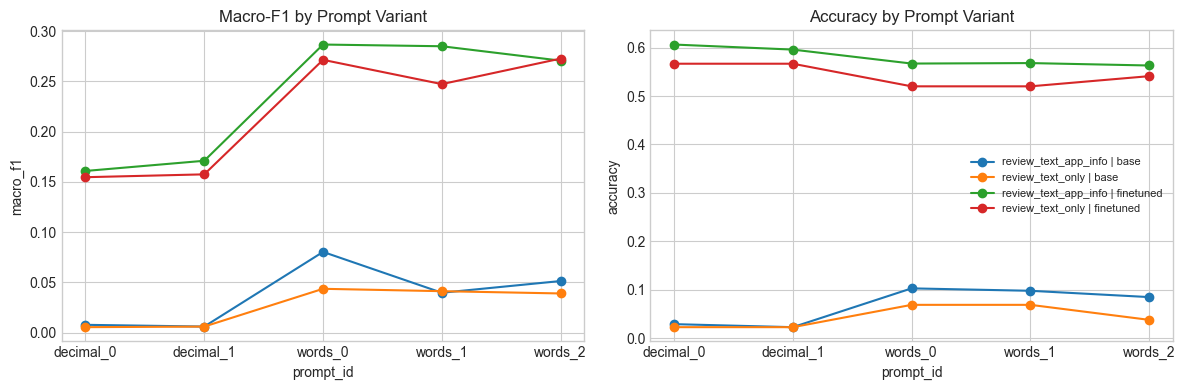

In [6]:
robustness = (
    summary_long_all
    .groupby(["variant", "stage", "prompt_family"])[["accuracy", "macro_f1"]]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

robustness.columns = [
    "variant", "stage", "prompt_family",
    "accuracy_mean", "accuracy_std", "accuracy_min", "accuracy_max",
    "macro_f1_mean", "macro_f1_std", "macro_f1_min", "macro_f1_max",
]

robustness["accuracy_range"] = robustness["accuracy_max"] - robustness["accuracy_min"]
robustness["macro_f1_range"] = robustness["macro_f1_max"] - robustness["macro_f1_min"]

robustness = robustness.sort_values(["prompt_family", "stage", "macro_f1_std"]).reset_index(drop=True)

print("Prompt robustness summary (smaller std/range is better):")
display(robustness.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], "macro_f1", "Macro-F1 by Prompt Variant"),
    (axes[1], "accuracy", "Accuracy by Prompt Variant"),
]:
    for stage in STAGE_ORDER:
        subset = summary_long_all[summary_long_all["stage"] == stage]
        grouped = subset.groupby(["variant", "prompt_id"], as_index=False)[metric].mean()
        grouped["key"] = grouped["variant"] + " | " + stage
        for key, g in grouped.groupby("key"):
            g = g.sort_values("prompt_id")
            ax.plot(g["prompt_id"], g[metric], marker="o", label=key)

    ax.set_title(title)
    ax.set_xlabel("prompt_id")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)

handles, labels = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1].legend(by_label.values(), by_label.keys(), fontsize=8)

plt.tight_layout()


## Load Prediction Files

Read `base_predictions.csv` and `finetuned_predictions.csv` so we can inspect class distributions directly.


In [7]:
prediction_frames = []
prediction_meta = []

for variant in VARIANT_ORDER:
    artifacts_root = bundles[variant]["artifacts_root"]
    for prompt_dir in sorted([p for p in artifacts_root.iterdir() if p.is_dir()]):
        prompt_id = prompt_dir.name
        label_family = prompt_id.split("_")[0]

        for stage, filename in [("base", "base_predictions.csv"), ("finetuned", "finetuned_predictions.csv")]:
            path = prompt_dir / filename
            if not path.exists():
                continue

            df = pd.read_csv(path)
            df["variant"] = variant
            df["stage"] = stage
            df["prompt_id"] = prompt_id
            df["prompt_family"] = label_family
            prediction_frames.append(df)

            prediction_meta.append(
                {
                    "variant": variant,
                    "stage": stage,
                    "prompt_id": prompt_id,
                    "prompt_family": label_family,
                    "rows": len(df),
                    "path": str(path),
                }
            )

if not prediction_frames:
    raise RuntimeError("No prediction CSV files found in artifacts.")

predictions_all = pd.concat(prediction_frames, ignore_index=True)
prediction_manifest = pd.DataFrame(prediction_meta)

print(f"Loaded prediction files: {len(prediction_frames)}")
print(f"Loaded prediction rows: {len(predictions_all):,}")
display(prediction_manifest.sort_values(["variant", "stage", "prompt_id"]).reset_index(drop=True))

preview_n = min(6, len(prediction_frames))
print(f"Previewing first {preview_n} prediction frames (head=3 rows each):")
for meta, frame in zip(prediction_meta[:preview_n], prediction_frames[:preview_n]):
    print(f"\n{meta['variant']} | {meta['stage']} | {meta['prompt_id']} | rows={meta['rows']}")
    display(frame.head(3))



Loaded prediction files: 20
Loaded prediction rows: 15,840


,variant,stage,prompt_id,prompt_family,rows,path
0,review_text_app_info,base,decimal_0,decimal,480,models\bert_finetuned_mlm\review_text_app_info...
1,review_text_app_info,base,decimal_1,decimal,480,models\bert_finetuned_mlm\review_text_app_info...
2,review_text_app_info,base,words_0,words,1000,models\bert_finetuned_mlm\review_text_app_info...
3,review_text_app_info,base,words_1,words,1000,models\bert_finetuned_mlm\review_text_app_info...
4,review_text_app_info,base,words_2,words,1000,models\bert_finetuned_mlm\review_text_app_info...
5,review_text_app_info,finetuned,decimal_0,decimal,480,models\bert_finetuned_mlm\review_text_app_info...
6,review_text_app_info,finetuned,decimal_1,decimal,480,models\bert_finetuned_mlm\review_text_app_info...
7,review_text_app_info,finetuned,words_0,words,1000,models\bert_finetuned_mlm\review_text_app_info...
8,review_text_app_info,finetuned,words_1,words,1000,models\bert_finetuned_mlm\review_text_app_info...
9,review_text_app_info,finetuned,words_2,words,1000,models\bert_finetuned_mlm\review_text_app_info...


Previewing first 6 prediction frames (head=3 rows each):

review_text_only | base | decimal_0 | rows=480


,review_id,true_label,pred_label,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,true_word,pred_word,true_prob,variant,stage,prompt_id,prompt_family
0,209594247,5,5,0.200306,0.054528,0.063446,0.030666,0.045933,0.259496,0.090037,0.033304,0.112060,0.110225,5,5,0.259496,review_text_only,base,decimal_0,decimal
1,83925293,0,5,0.110261,0.065082,0.055895,0.024313,0.028468,0.329509,0.095351,0.039545,0.129914,0.121664,0,5,0.110261,review_text_only,base,decimal_0,decimal
2,24948264,9,5,0.194097,0.060102,0.046904,0.022114,0.034044,0.303409,0.083376,0.032627,0.109933,0.113395,9,5,0.113395,review_text_only,base,decimal_0,decimal



review_text_only | finetuned | decimal_0 | rows=480


...

,review_id,true_label,pred_label,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,true_word,pred_word,true_prob,variant,stage,prompt_id,prompt_family
0,209594247,5,1,0.116886,0.577499,0.158958,0.049424,0.021909,0.014406,0.016357,0.006648,0.004133,0.033781,5,1,0.014406,review_text_only,finetuned,decimal_1,decimal
1,83925293,0,9,0.004305,0.186621,0.099668,0.094112,0.078682,0.059885,0.067161,0.057525,0.028415,0.323626,0,9,0.004305,review_text_only,finetuned,decimal_1,decimal
2,24948264,9,9,0.010218,0.257561,0.126608,0.119539,0.051901,0.042175,0.043950,0.036647,0.020995,0.290406,9,9,0.290406,review_text_only,finetuned,decimal_1,decimal



review_text_only | base | words_0 | rows=1000


,review_id,true_label,pred_label,prob_serious,prob_witty,prob_amusing,prob_hilarious,prob_hysterical,true_word,pred_word,true_prob,variant,stage,prompt_id,prompt_family
0,212762582,1,3,0.013397,0.009325,0.324406,0.645513,0.007359,witty,hilarious,0.009325,review_text_only,base,words_0,words
1,213514533,1,2,0.009674,0.014656,0.579417,0.367440,0.028812,witty,amusing,0.014656,review_text_only,base,words_0,words
2,201269134,0,2,0.041105,0.123632,0.490640,0.333565,0.011057,serious,amusing,0.041105,review_text_only,base,words_0,words



review_text_only | finetuned | words_0 | rows=1000


,review_id,true_label,pred_label,prob_serious,prob_witty,prob_amusing,prob_hilarious,prob_hysterical,true_word,pred_word,true_prob,variant,stage,prompt_id,prompt_family
0,212762582,1,1,0.015128,0.447078,0.443704,0.045234,0.048856,witty,witty,0.447078,review_text_only,finetuned,words_0,words
1,213514533,1,0,0.651612,0.329803,0.016711,0.001190,0.000685,witty,serious,0.329803,review_text_only,finetuned,words_0,words
2,201269134,0,0,0.832661,0.163556,0.003404,0.000250,0.000129,serious,serious,0.832661,review_text_only,finetuned,words_0,words


## Decimal Prompt Distribution Diagnostics (Class `5` Check)

For decimal prompts, compare prediction distributions under all four conditions:
- `review_text_only | base`
- `review_text_only | finetuned`
- `review_text_app_info | base`
- `review_text_app_info | finetuned`


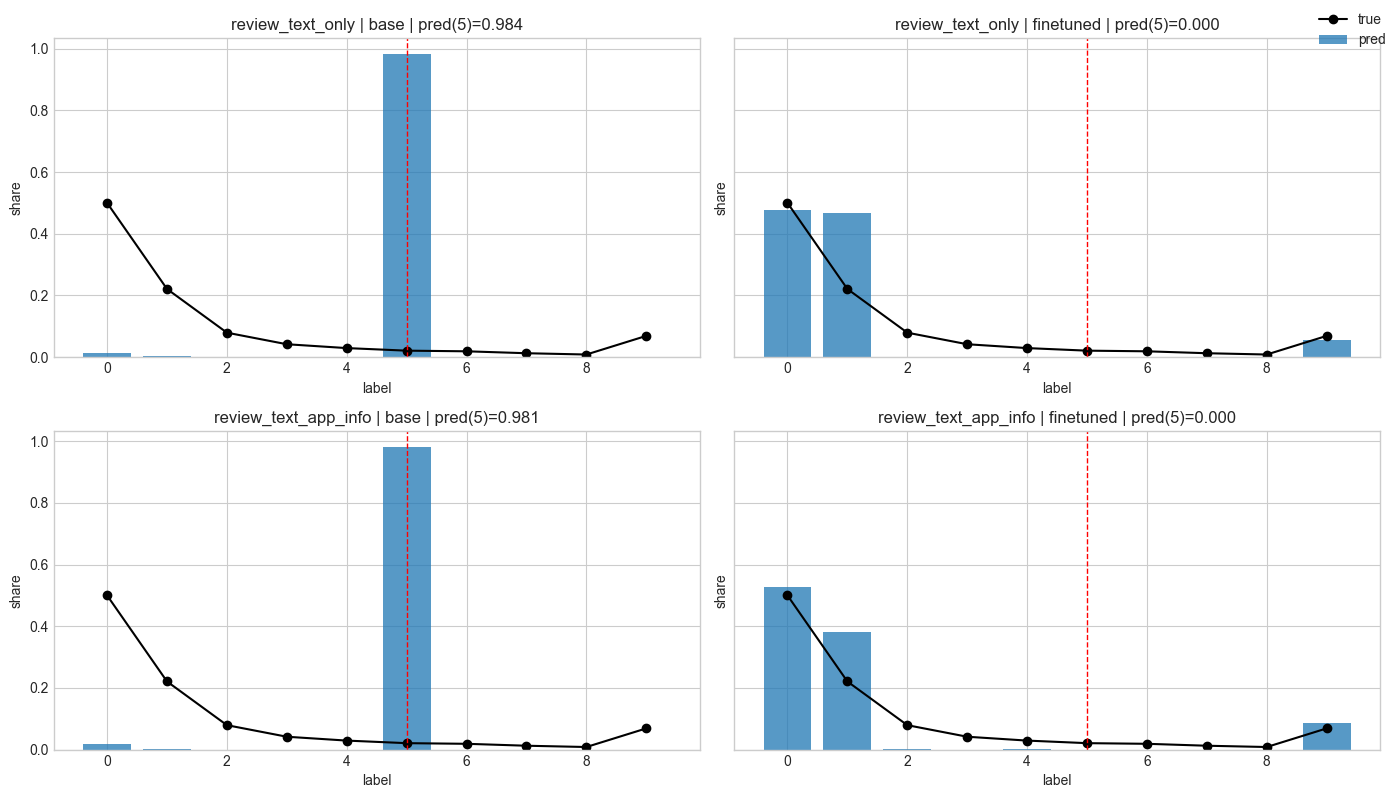

In [8]:
decimal_preds = predictions_all[predictions_all["prompt_family"] == "decimal"].copy()
if decimal_preds.empty:
    raise RuntimeError("No decimal prompt predictions found.")

label_values = sorted(set(decimal_preds["true_label"].unique()) | set(decimal_preds["pred_label"].unique()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

for r, variant in enumerate(VARIANT_ORDER):
    for c, stage in enumerate(STAGE_ORDER):
        ax = axes[r, c]
        subset = decimal_preds[(decimal_preds["variant"] == variant) & (decimal_preds["stage"] == stage)]

        pred_dist = subset["pred_label"].value_counts(normalize=True).reindex(label_values, fill_value=0.0)
        true_dist = subset["true_label"].value_counts(normalize=True).reindex(label_values, fill_value=0.0)

        ax.bar(label_values, pred_dist.values, alpha=0.75, label="pred")
        ax.plot(label_values, true_dist.values, color="black", marker="o", linewidth=1.5, label="true")
        ax.axvline(5, color="red", linestyle="--", linewidth=1)

        p5 = float(pred_dist.loc[5]) if 5 in pred_dist.index else 0.0
        ax.set_title(f"{variant} | {stage} | pred(5)={p5:.3f}")
        ax.set_xlabel("label")
        ax.set_ylabel("share")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()


In [9]:
# Quantify class-5 concentration by prompt and by 2x2 group.

def top_label_stats(df: pd.DataFrame) -> pd.Series:
    vc = df["pred_label"].value_counts(normalize=True)
    return pd.Series({
        "top_pred_label": int(vc.index[0]),
        "top_pred_share": float(vc.iloc[0]),
        "predicted_5_share": float(vc.get(5, 0.0)),
        "rows": int(len(df)),
    })

class5_by_prompt = (
    decimal_preds.groupby(["variant", "stage", "prompt_id"], as_index=False)
    .apply(top_label_stats, include_groups=False)
)

class5_by_group = (
    decimal_preds.groupby(["variant", "stage"], as_index=False)
    .apply(top_label_stats, include_groups=False)
)

print("Decimal prompts: concentration by prompt")
display(class5_by_prompt.sort_values(["variant", "stage", "predicted_5_share"], ascending=[True, True, False]).round(4))

print("Decimal prompts: concentration aggregated by 2x2 group")
display(class5_by_group.sort_values(["variant", "stage"]).round(4))


Decimal prompts: concentration by prompt


,variant,stage,prompt_id,top_pred_label,top_pred_share,predicted_5_share,rows
1,review_text_app_info,base,decimal_1,5.0,0.9979,0.9979,480.0
0,review_text_app_info,base,decimal_0,5.0,0.9646,0.9646,480.0
2,review_text_app_info,finetuned,decimal_0,0.0,0.5500,0.0000,480.0
3,review_text_app_info,finetuned,decimal_1,0.0,0.5042,0.0000,480.0
5,review_text_only,base,decimal_1,5.0,0.9958,0.9958,480.0
4,review_text_only,base,decimal_0,5.0,0.9729,0.9729,480.0
6,review_text_only,finetuned,decimal_0,0.0,0.4854,0.0000,480.0
7,review_text_only,finetuned,decimal_1,1.0,0.4667,0.0000,480.0


Decimal prompts: concentration aggregated by 2x2 group


,variant,stage,top_pred_label,top_pred_share,predicted_5_share,rows
0,review_text_app_info,base,5.0,0.9812,0.9812,960.0
1,review_text_app_info,finetuned,0.0,0.5271,0.0000,960.0
2,review_text_only,base,5.0,0.9844,0.9844,960.0
3,review_text_only,finetuned,0.0,0.4760,0.0000,960.0


## Word Prompt Distribution Diagnostics

Same 2x2 view for `words_*` prompts to check whether predictions are balanced and whether one class dominates.


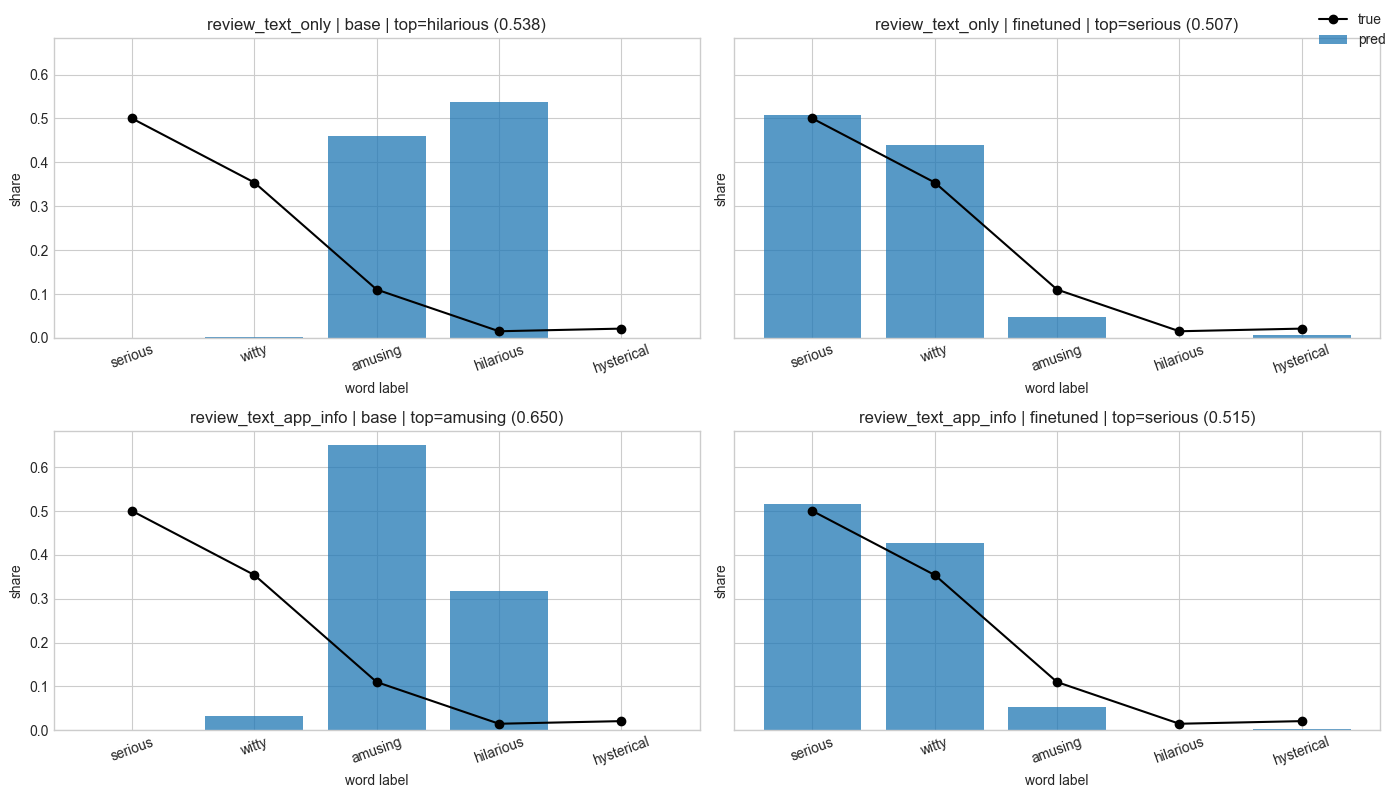

In [10]:
word_preds = predictions_all[predictions_all["prompt_family"] == "words"].copy()
if word_preds.empty:
    raise RuntimeError("No word prompt predictions found.")

label_values_words = sorted(set(word_preds["true_label"].unique()) | set(word_preds["pred_label"].unique()))

label_name_map = {}
for lbl in label_values_words:
    candidates = pd.concat([
        word_preds.loc[word_preds["true_label"] == lbl, "true_word"],
        word_preds.loc[word_preds["pred_label"] == lbl, "pred_word"],
    ], ignore_index=True).dropna().astype(str)
    label_name_map[lbl] = candidates.mode().iloc[0] if not candidates.empty else str(lbl)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

x = np.arange(len(label_values_words))

for r, variant in enumerate(VARIANT_ORDER):
    for c, stage in enumerate(STAGE_ORDER):
        ax = axes[r, c]
        subset = word_preds[(word_preds["variant"] == variant) & (word_preds["stage"] == stage)]

        pred_dist = subset["pred_label"].value_counts(normalize=True).reindex(label_values_words, fill_value=0.0)
        true_dist = subset["true_label"].value_counts(normalize=True).reindex(label_values_words, fill_value=0.0)

        ax.bar(x, pred_dist.values, alpha=0.75, label="pred")
        ax.plot(x, true_dist.values, color="black", marker="o", linewidth=1.5, label="true")

        top_label = int(pred_dist.idxmax())
        top_label_name = label_name_map.get(top_label, str(top_label))
        top_share = float(pred_dist.max())
        ax.set_title(f"{variant} | {stage} | top={top_label_name} ({top_share:.3f})")
        ax.set_xticks(x)
        ax.set_xticklabels([label_name_map[l] for l in label_values_words], rotation=20)
        ax.set_xlabel("word label")
        ax.set_ylabel("share")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()


In [11]:
def word_top_label_stats(df: pd.DataFrame) -> pd.Series:
    vc = df["pred_label"].value_counts(normalize=True)
    top_label = int(vc.index[0])
    return pd.Series({
        "top_pred_label": top_label,
        "top_pred_word": label_name_map.get(top_label, str(top_label)),
        "top_pred_share": float(vc.iloc[0]),
        "predicted_serious_share": float(vc.get(0, 0.0)),
        "rows": int(len(df)),
    })

word_by_prompt = (
    word_preds.groupby(["variant", "stage", "prompt_id"], as_index=False)
    .apply(word_top_label_stats, include_groups=False)
)

word_by_group = (
    word_preds.groupby(["variant", "stage"], as_index=False)
    .apply(word_top_label_stats, include_groups=False)
)

print("Word prompts: concentration by prompt")
display(word_by_prompt.sort_values(["variant", "stage", "top_pred_share"], ascending=[True, True, False]).round(4))

print("Word prompts: concentration aggregated by 2x2 group")
display(word_by_group.sort_values(["variant", "stage"]).round(4))


Word prompts: concentration by prompt


,variant,stage,prompt_id,top_pred_label,top_pred_word,top_pred_share,predicted_serious_share,rows
1,review_text_app_info,base,words_1,2,amusing,0.879,0.000,1000
2,review_text_app_info,base,words_2,2,amusing,0.605,0.000,1000
0,review_text_app_info,base,words_0,2,amusing,0.466,0.000,1000
3,review_text_app_info,finetuned,words_0,0,serious,0.552,0.552,1000
5,review_text_app_info,finetuned,words_2,0,serious,0.524,0.524,1000
4,review_text_app_info,finetuned,words_1,1,witty,0.475,0.470,1000
8,review_text_only,base,words_2,3,hilarious,0.767,0.000,1000
7,review_text_only,base,words_1,2,amusing,0.592,0.000,1000
6,review_text_only,base,words_0,2,amusing,0.558,0.000,1000
11,review_text_only,finetuned,words_2,0,serious,0.523,0.523,1000


Word prompts: concentration aggregated by 2x2 group


,variant,stage,top_pred_label,top_pred_word,top_pred_share,predicted_serious_share,rows
0,review_text_app_info,base,2,amusing,0.6500,0.0000,3000
1,review_text_app_info,finetuned,0,serious,0.5153,0.5153,3000
2,review_text_only,base,3,hilarious,0.5383,0.0000,3000
3,review_text_only,finetuned,0,serious,0.5070,0.5070,3000


## Inspect Stored Confusion Matrices (All Combinations)

This cell displays every available confusion matrix across all:
- text variants
- prompt IDs
- stages (`base`, `finetuned`)



In [12]:
# Display all confusion matrices for every variant x prompt x stage combination.

available_count = 0
missing = []

for variant in VARIANT_ORDER:
    artifacts_root = bundles[variant]["artifacts_root"]
    prompt_dirs = sorted([p for p in artifacts_root.iterdir() if p.is_dir()])

    for prompt_dir in prompt_dirs:
        prompt_id = prompt_dir.name
        for stage in STAGE_ORDER:
            conf_path = prompt_dir / f"{stage}_confusion_matrix.csv"

            if conf_path.exists():
                available_count += 1
                print()
                print(f"Variant={variant} | prompt_id={prompt_id} | stage={stage}")
                conf_df = pd.read_csv(conf_path, index_col=0)
                display(conf_df)
            else:
                missing.append(
                    {
                        "variant": variant,
                        "prompt_id": prompt_id,
                        "stage": stage,
                        "path": str(conf_path),
                    }
                )

print()
print(f"Displayed confusion matrices: {available_count}")

if missing:
    print(f"Missing confusion matrices: {len(missing)}")
    display(pd.DataFrame(missing))
else:
    print("No missing confusion matrices.")




Variant=review_text_only | prompt_id=decimal_0 | stage=base


,0,5
true,,
0,2,238
1,6,100
2,0,38
3,1,19
4,0,14
5,1,9
6,1,8
7,0,6
8,1,3



Variant=review_text_only | prompt_id=decimal_0 | stage=finetuned


,0,1,9
true,,,
0,187,50,3
1,25,77,4
2,9,28,1
3,3,16,1
4,0,12,2
5,2,6,2
6,1,7,1
7,1,5,0
8,1,3,0



Variant=review_text_only | prompt_id=decimal_1 | stage=base


...


Variant=review_text_app_info | prompt_id=words_2 | stage=base


,2,3
true,,
0,284,216
1,227,127
2,76,34
3,6,9
4,12,9



Variant=review_text_app_info | prompt_id=words_2 | stage=finetuned


,0,1,2,3,4
true,,,,,
0,352,140,7,0,1
1,136,199,16,1,2
2,29,69,12,0,0
3,4,5,5,0,1
4,3,16,2,0,0



Displayed confusion matrices: 20
No missing confusion matrices.
